Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.955557..3.6111305].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4162543..3.2573526].


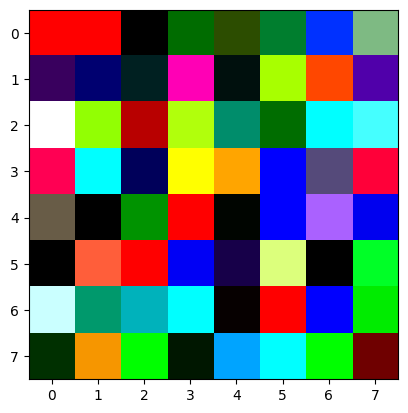

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import einops

key = jax.random.key(0)

matrix = jax.random.normal(key, shape=(3, 64, 64))
plt.imshow(matrix.transpose(-2, -1, 0))

# patchify func
def patchify(a):
    return einops.rearrange(a, 'c (h d1) (w d2) -> (h w) c d1 d2', d1=8, d2=8)

#viz first patch
plt.imshow(patchify(matrix)[0].transpose(-2, -1, 0))


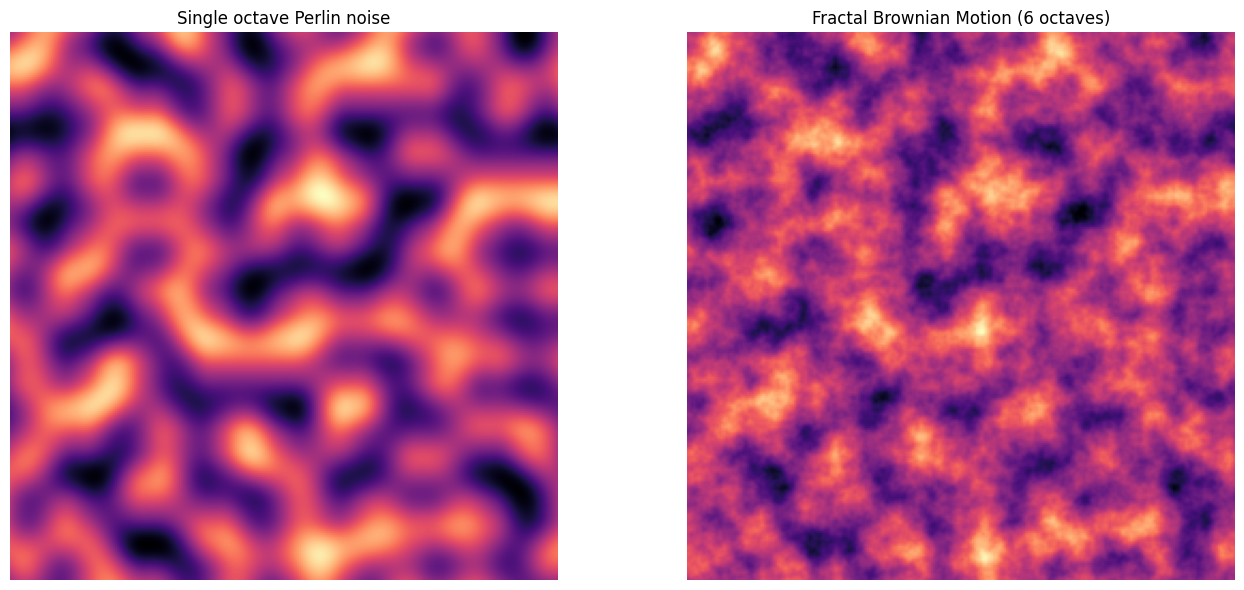

In [10]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import einops

key = jax.random.key(0)

# ═══════════════════════════════════════════════════════════════
# PERLIN NOISE — JAX Implementation
# ═══════════════════════════════════════════════════════════════

# ── Step 1: Permutation table for hashing lattice points ──────
# At each integer coordinate we need a reproducible pseudo-random
# value. Classic Perlin uses a shuffled permutation table P of
# 0..255, then hashes coordinates via:  P[P[ix] + iy]
# We tile it to length 512 so we never need modular arithmetic.
perm = jax.random.permutation(key, 256)
perm = jnp.concatenate([perm, perm])  # (512,)

# ── Step 2: Gradient vectors ─────────────────────────────────
# For 2D noise each lattice point gets a pseudo-random unit-length
# gradient. We pre-define 8 evenly spaced directions and select
# one per lattice point using the hash.
angles = jnp.linspace(0, 2 * jnp.pi, 8, endpoint=False)
GRADS = jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=-1)  # (8, 2)


def hash2d(ix, iy):
    """Hash 2D integer coords → index into gradient table.
    
    Uses the permutation table: hash = P[P[ix % 256] + iy % 256]
    This gives a deterministic but pseudo-random mapping from
    any integer lattice point (ix, iy) to a gradient index.
    """
    ix = ix.astype(jnp.int32) % 256
    iy = iy.astype(jnp.int32) % 256
    return perm[perm[ix] + iy] % 8  # 8 gradient directions


def dot_grad(ix, iy, x, y):
    """Compute dot(gradient_at(ix,iy), (x - ix, y - iy)).
    
    This is the core Perlin idea: the noise value contributed by
    each corner is the dot product of:
      - the pseudo-random gradient assigned to that corner
      - the vector FROM the corner TO the sample point
    
    At a corner itself this dot product = 0 (distance vector = 0),
    which is why Perlin noise always passes through zero at
    integer coordinates.
    """
    grad_idx = hash2d(ix, iy)
    grad = GRADS[grad_idx]  # (... , 2)
    dx = x - ix.astype(jnp.float32)
    dy = y - iy.astype(jnp.float32)
    return grad[..., 0] * dx + grad[..., 1] * dy


def fade(t):
    """Hermite smoothstep: 6t⁵ - 15t⁴ + 10t³  (improved Perlin 2002).
    
    Original Perlin (1985) used 3t² - 2t³, which has zero first
    derivative at 0 and 1 but non-zero SECOND derivative →
    visible artifacts. The improved curve has C² continuity:
    
        fade(0)=0, fade(1)=1
        fade'(0)=0, fade'(1)=0
        fade''(0)=0, fade''(1)=0   ← this is the improvement
    
    This makes the interpolation much smoother.
    """
    return t * t * t * (t * (t * 6.0 - 15.0) + 10.0)


def perlin2d(x, y):
    """Evaluate 2D Perlin noise at continuous coordinates (x, y).
    
    Algorithm:
    1. Find the unit square [i, i+1] × [j, j+1] containing (x,y)
    2. Compute distance vectors from each of the 4 corners
    3. Dot each distance vector with the corner's gradient
    4. Interpolate using the Hermite fade curve
    
         (i,j+1)────────(i+1,j+1)
           │    ·(x,y)      │
           │                 │
         (i,j)──────────(i+1,j)
    """
    # Integer coords of the bottom-left corner of the unit square
    i = jnp.floor(x).astype(jnp.int32)
    j = jnp.floor(y).astype(jnp.int32)

    # Fractional position within the cell: u,v ∈ [0, 1)
    u = x - i.astype(jnp.float32)
    v = y - j.astype(jnp.float32)

    # ── Step 3: Dot products at the 4 corners ────────────────
    # Each corner contributes: dot(gradient, distance_to_sample)
    n00 = dot_grad(i,     j,     x, y)  # bottom-left
    n10 = dot_grad(i + 1, j,     x, y)  # bottom-right
    n01 = dot_grad(i,     j + 1, x, y)  # top-left
    n11 = dot_grad(i + 1, j + 1, x, y)  # top-right

    # ── Step 4: Hermite interpolation ────────────────────────
    # Apply the fade curve to get smooth interpolation weights
    su = fade(u)
    sv = fade(v)

    # Bilinear interpolation with faded weights:
    #   lerp in x at y=j  :  mix(n00, n10, su)
    #   lerp in x at y=j+1:  mix(n01, n11, su)
    #   lerp in y          :  mix(above_two, sv)
    x0 = n00 + su * (n10 - n00)  # bottom edge interpolation
    x1 = n01 + su * (n11 - n01)  # top edge interpolation
    return x0 + sv * (x1 - x0)   # final vertical interpolation


# ═══════════════════════════════════════════════════════════════
# Generate a 2D noise field & visualise
# ═══════════════════════════════════════════════════════════════
SIZE = 256
SCALE = 32.0  # lower → more zoomed in (larger features)

# Build a grid of sample coordinates
xs = jnp.linspace(0, SIZE / SCALE, SIZE, endpoint=False)
ys = jnp.linspace(0, SIZE / SCALE, SIZE, endpoint=False)
gx, gy = jnp.meshgrid(xs, ys)

# Evaluate noise at every pixel
noise = perlin2d(gx, gy)

# ── Octave / fractal noise (fBm) ────────────────────────────
# Layering multiple frequencies ("octaves") produces richer,
# more natural-looking textures. Each octave doubles the
# frequency and halves the amplitude.
def fbm(x, y, octaves=6, lacunarity=2.0, gain=0.5):
    """Fractal Brownian Motion — sum of Perlin octaves."""
    value = jnp.zeros_like(x)
    amplitude = 1.0
    freq = 1.0
    for _ in range(octaves):
        value = value + amplitude * perlin2d(x * freq, y * freq)
        freq *= lacunarity   # double frequency
        amplitude *= gain    # halve amplitude
    return value

noise_fbm = fbm(gx, gy, octaves=6)

# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(noise, cmap='magma', origin='lower')
axes[0].set_title('Single octave Perlin noise')
axes[0].axis('off')

axes[1].imshow(noise_fbm, cmap='magma', origin='lower')
axes[1].set_title('Fractal Brownian Motion (6 octaves)')
axes[1].axis('off')

plt.tight_layout()
plt.show()